In [1]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [3]:
data = pd.read_csv('../data/cleaned_merged_dataset.csv')

zscore_columns = [
'HALE_Birth', 'HALE_60',
'infant mortality rate (between birth and 11 months per 1000 live births)',
'Age-standardized suicide rates (per 100 000 population)',
'Alcohol, total per capita (15+ years) consumption (in litres of pure alcohol) (SDG Indicator 3.5.2)',
'Estimates of rate of homicides (per 100 000 population)',
'Mean Total Cholesterol (crude estimate)',
'PM2.5_Exposure', 'Health_Expenditure_pct_GDP'
]

percentage_columns = [
'Prevalence of insufficient physical activity among adults aged 18+ years (age-standardized estimate) (%)',
'Prevalence of obesity among adults, BMI ³ 30 (age-standardized estimate) (%)',
'Prevalence of raised blood pressure among adults aged 30-79 years',
'Probability of dying between the exact ages 30 and 70 years from cardiovascular diseases, cancer, diabetes, or chronic respiratory diseases (SDG 3.4.1)',
'Undernourishment_Prevalence'
]

In [4]:
scaler_zscore = StandardScaler()
data[zscore_columns] = scaler_zscore.fit_transform(data[zscore_columns])

In [5]:
scaler_minmax = MinMaxScaler()
data[percentage_columns] = scaler_minmax.fit_transform(data[percentage_columns])

print("Normalization complete.")

Normalization complete.


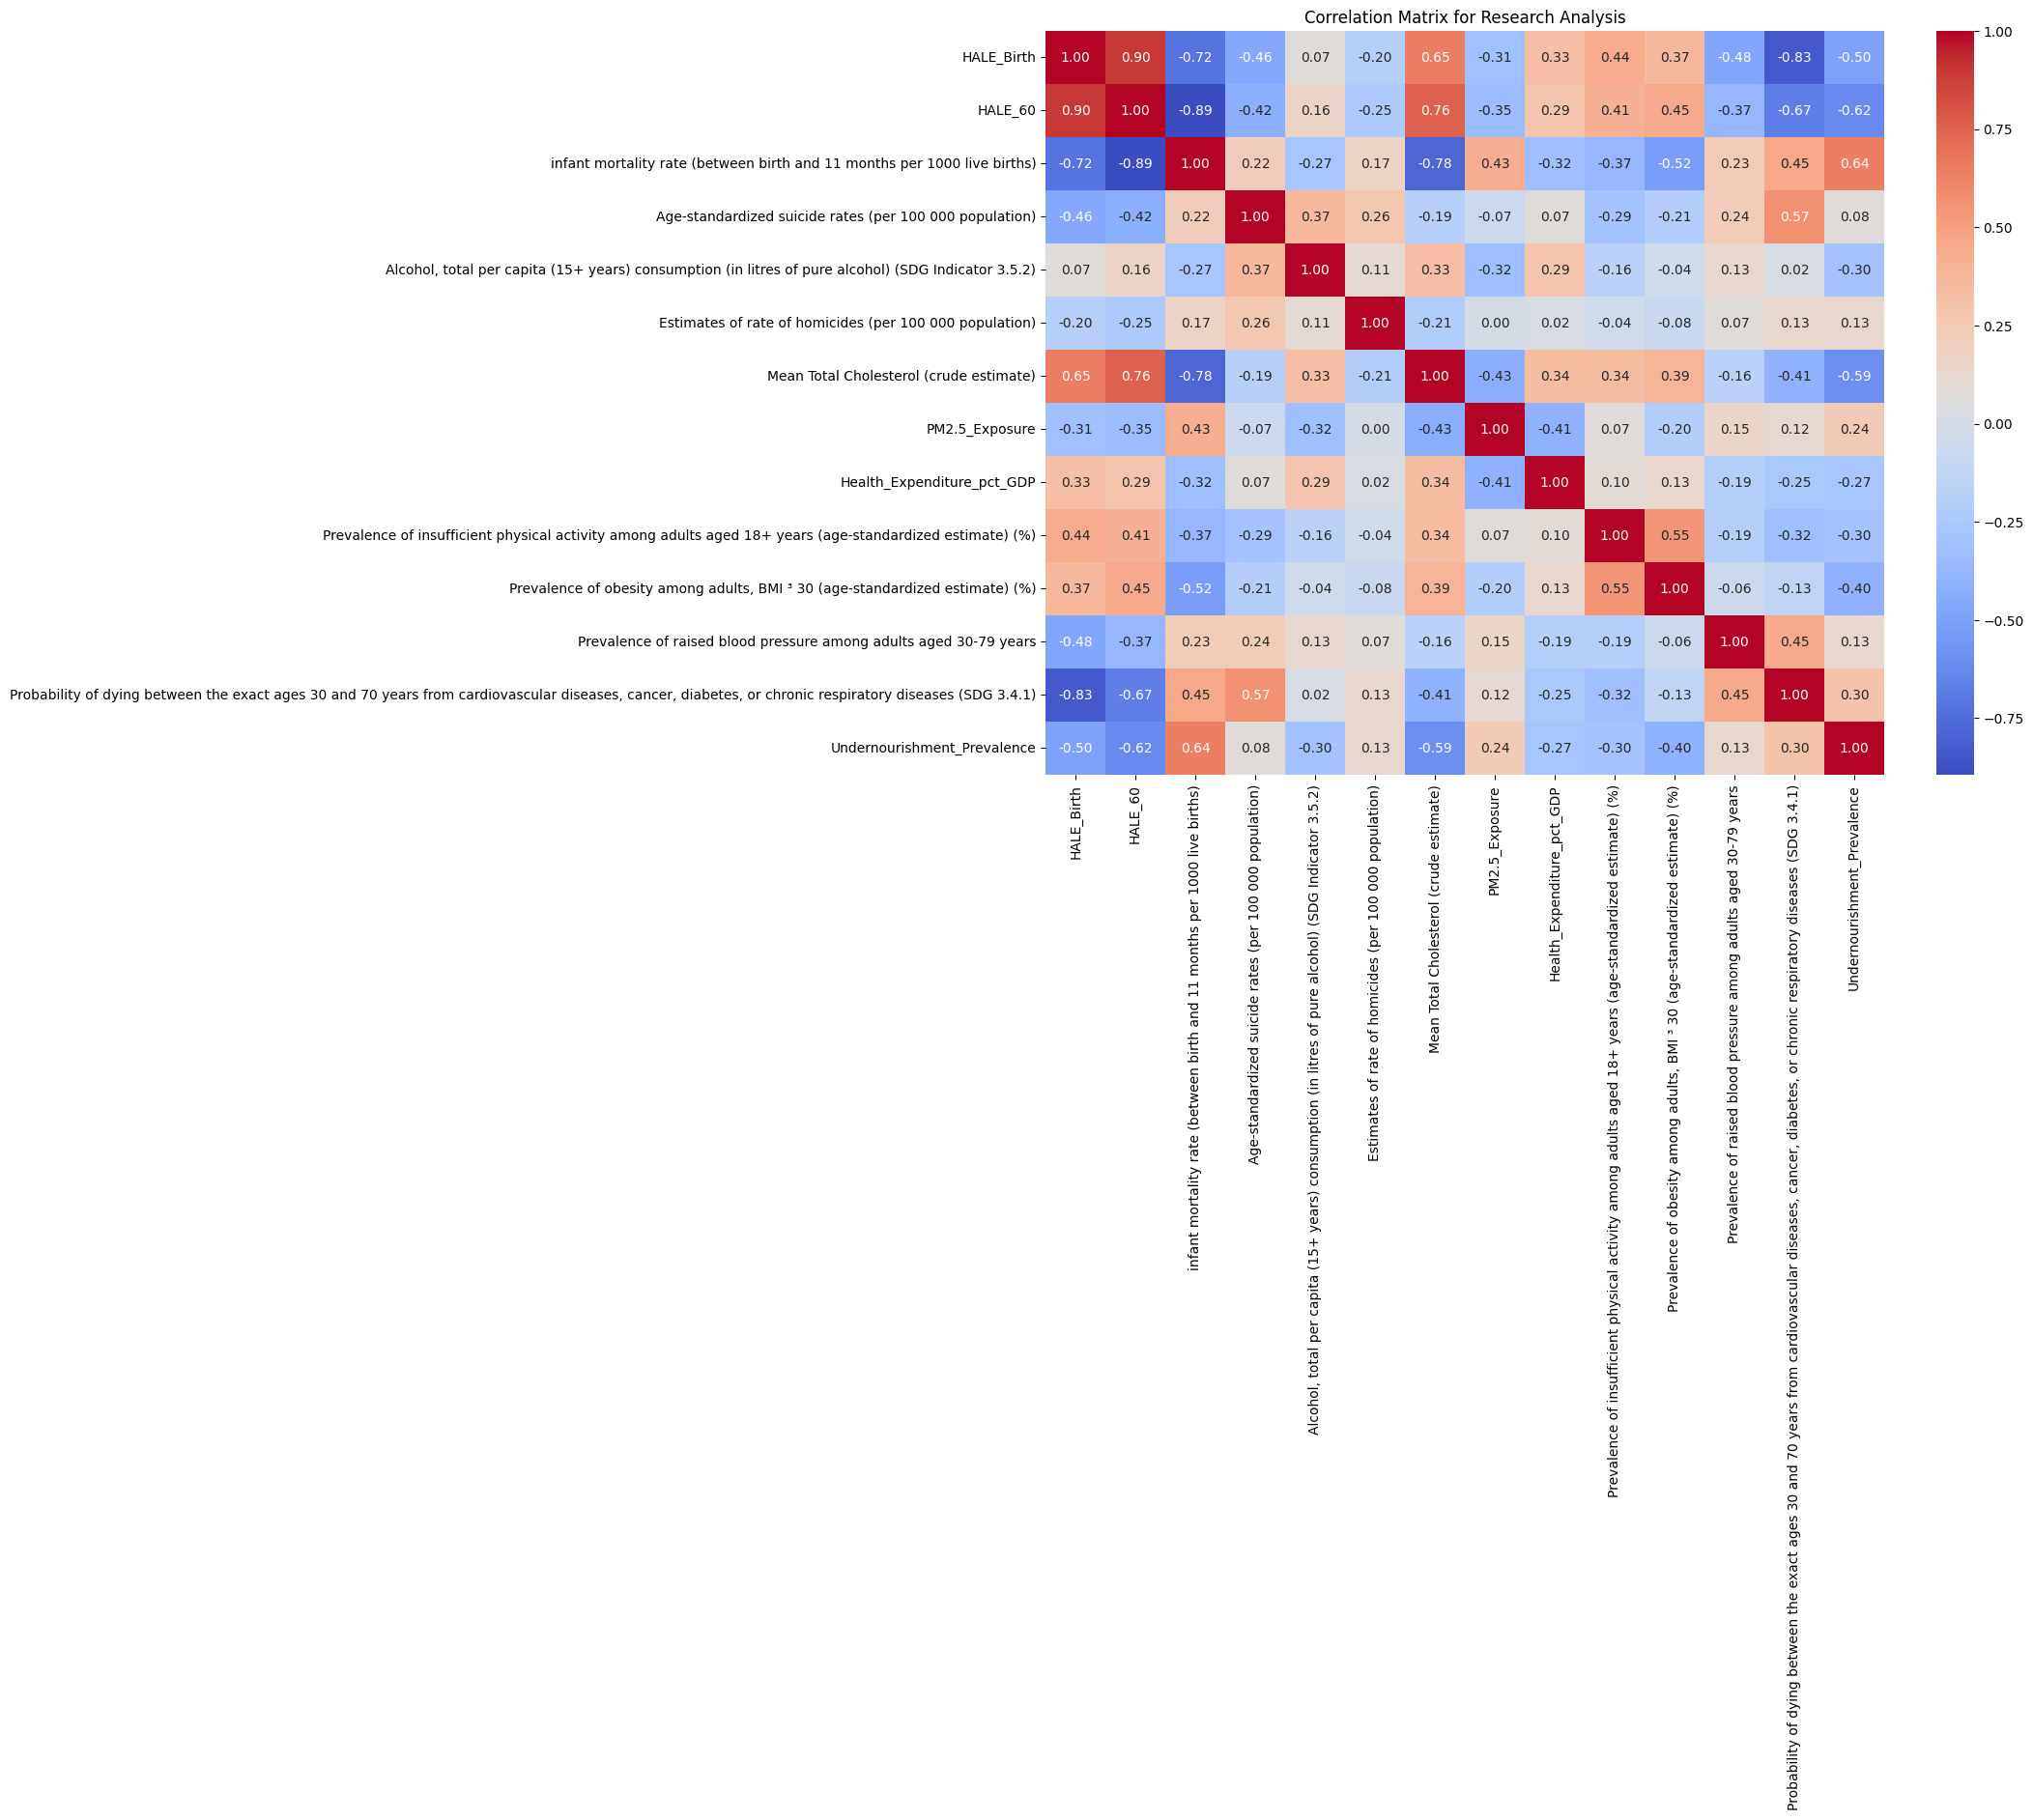

In [6]:
numerical_data = data[zscore_columns + percentage_columns]
plt.figure(figsize=(14, 10))
sns.heatmap(numerical_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix for Research Analysis')
plt.show()

In [7]:
data['Period_sin'] = np.sin(2 * np.pi * data['Period'] / data['Period'].max())
data['Period_cos'] = np.cos(2 * np.pi * data['Period'] / data['Period'].max())

data_final = pd.get_dummies(data, columns=['ParentLocation', 'Location', 'Dim1'], drop_first=True)

In [8]:
output_name = '../data/final_normalized_data_for_ML.csv'
data_final.to_csv(output_name, index=False)
print("Ready! File saved as:", output_name)

Ready! File saved as: ../data/final_normalized_data_for_ML.csv
